Using device: cpu


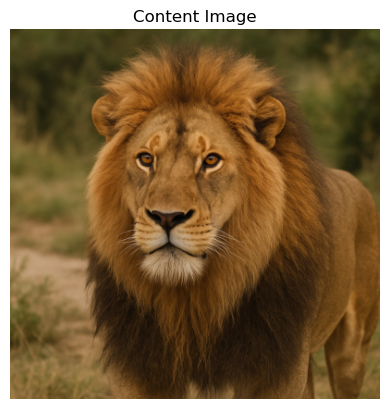

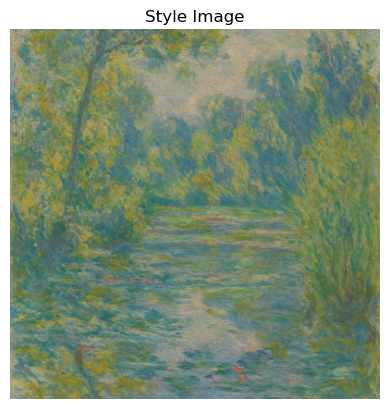

c:\Users\sharmila\anaconda3\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\sharmila\anaconda3\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Starting style transfer...
Step 50/200, Total Loss: 5440899.0000


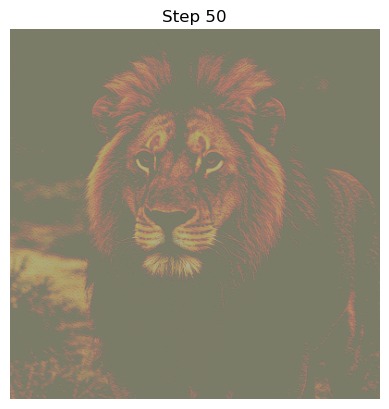

Step 100/200, Total Loss: 3064739.5000


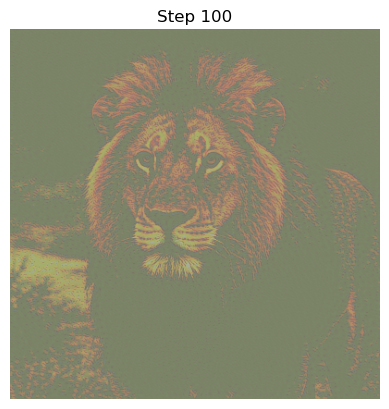

Step 150/200, Total Loss: 1769602.0000


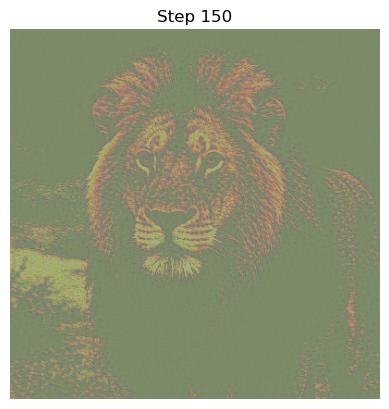

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load and preprocess image
def load_image(path, max_size=400, shape=None):
    image = Image.open(path).convert('RGB')

    if max(image.size) > max_size:
        size = max_size
    else:
        size = max(image.size)

    if shape is not None:
        size = [shape[-2], shape[-1]]  # extract (height, width)

    in_transform = transforms.Compose([
        transforms.Resize(size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    image = in_transform(image)[:3, :, :].unsqueeze(0)
    return image.to(device)

# Display image
def imshow(tensor, title=None):
    image = tensor.cpu().clone().detach().squeeze(0)
    image = image * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image = image + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    image = image.clamp(0, 1)
    plt.imshow(image.permute(1, 2, 0))
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()


# Load images
content_img = load_image("content.jpg")
style_img = load_image("style.jpg", shape=content_img.shape[-2:])

imshow(content_img, "Content Image")
imshow(style_img, "Style Image")

# Load pretrained VGG19
vgg = models.vgg19(pretrained=True).features.to(device).eval()

# Feature layers
content_layer = 'conv4_2'
style_layers = ['conv1_1', 'conv2_1', 'conv3_1', 'conv4_1', 'conv5_1']

# Map layer names
def get_features(image, model):
    layers = {
        '0': 'conv1_1',
        '5': 'conv2_1',
        '10': 'conv3_1',
        '19': 'conv4_1',
        '21': 'conv4_2',
        '28': 'conv5_1'
    }
    features = {}
    x = image
    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x
    return features

# Compute Gram matrix
def gram_matrix(tensor):
    b, c, h, w = tensor.size()
    tensor = tensor.view(c, h * w)
    gram = torch.mm(tensor, tensor.t())
    return gram

# Get features
content_features = get_features(content_img, vgg)
style_features = get_features(style_img, vgg)
style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_layers}

# Initialize target
target = content_img.clone().requires_grad_(True).to(device)

# Loss weights
style_weights = {'conv1_1': 1.0, 'conv2_1': 0.8, 'conv3_1': 0.5,
                 'conv4_1': 0.3, 'conv5_1': 0.1}
content_weight = 1e4
style_weight = 1e2

# Optimizer
optimizer = optim.Adam([target], lr=0.003)
steps = 200 # You can adjust this (try 200–500)

print("Starting style transfer...")
for step in range(1, steps + 1):
    optimizer.zero_grad()

    target_features = get_features(target, vgg)

    # Content loss (compare to *precomputed* content features)
    content_loss = torch.mean((target_features[content_layer] - content_features[content_layer].detach()) ** 2)

    # Style loss
    style_loss = 0
    for layer in style_layers:
        target_feature = target_features[layer]
        target_gram = gram_matrix(target_feature)
        style_gram = style_grams[layer].detach()
        layer_style_loss = style_weights[layer] * torch.mean((target_gram - style_gram) ** 2)
        style_loss += layer_style_loss / (target_feature.shape[1] ** 2)

    total_loss = content_weight * content_loss + style_weight * style_loss
    total_loss.backward()
    optimizer.step()

    # Clamp to [0, 1]
    with torch.no_grad():
        target.clamp_(0, 1)

    if step % 50 == 0:
        print(f"Step {step}/{steps}, Total Loss: {total_loss.item():.4f}")
        imshow(target, f"Step {step}")
